# kNN Classification — Online Retail Dataset

This notebook applies the k-Nearest Neighbours classifier to the Online Retail dataset. The aim is to classify customers as high-value or low-value based on their purchasing behaviour.

The model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrix analysis. Hyperparameter tuning is applied to improve the final model performance.

In [3]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
# =====================================================
# 2. LOAD ONLINE RETAIL DATASET
# =====================================================

retail_2009 = pd.read_excel(
    "../dataset/online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

retail_2010 = pd.read_excel(
    "../dataset/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

retail = pd.concat(
    [retail_2009, retail_2010],
    ignore_index=True
)

print("Combined Retail Dataset Shape:", retail.shape)

display(retail.head())

Combined Retail Dataset Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# =====================================================
# 3. RETAIL DATA CLEANING
# =====================================================

retail_clean = retail.copy()

original_shape = retail_clean.shape

# Remove missing Customer IDs
retail_clean = retail_clean.dropna(subset=["Customer ID"])

# Remove cancelled invoices
retail_clean = retail_clean[
    ~retail_clean["Invoice"].astype(str).str.startswith("C")
]

# Remove invalid Quantity and Price values
retail_clean = retail_clean[retail_clean["Quantity"] > 0]
retail_clean = retail_clean[retail_clean["Price"] > 0]

# Convert InvoiceDate to datetime
retail_clean["InvoiceDate"] = pd.to_datetime(
    retail_clean["InvoiceDate"],
    errors="coerce"
)

# Remove invalid dates
retail_clean = retail_clean.dropna(subset=["InvoiceDate"])

# Create TotalPrice
retail_clean["TotalPrice"] = (
    retail_clean["Quantity"] * retail_clean["Price"]
)

# Remove duplicate rows
retail_clean = retail_clean.drop_duplicates()

# Reset index
retail_clean = retail_clean.reset_index(drop=True)

print("Original Shape:", original_shape)
print("Cleaned Shape:", retail_clean.shape)

display(retail_clean.head())

Original Shape: (1067371, 8)
Cleaned Shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
# =====================================================
# 4. RFM FEATURE ENGINEERING
# =====================================================

snapshot_date = retail_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail_clean.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AverageBasketValue=("TotalPrice", "mean"),
    TotalQuantity=("Quantity", "sum")
).reset_index()

rfm = rfm.rename(columns={"Customer ID": "CustomerID"})

# Log transformations to reduce skewness
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Recency_log"] = np.log1p(rfm["Recency"])

# Create target variable — top 25% by Monetary value = high-value
threshold = rfm["Monetary"].quantile(0.75)

rfm["HighValueCustomer"] = (
    rfm["Monetary"] >= threshold
).astype(int)

print("RFM Shape:", rfm.shape)

print("\nHigh Value Customer Distribution:")
display(rfm["HighValueCustomer"].value_counts().to_frame("Count"))

display(rfm.head())

RFM Shape: (5878, 10)

High Value Customer Distribution:


,Count
HighValueCustomer,
0,4408
1,1470


,CustomerID,Recency,Frequency,Monetary,AverageBasketValue,TotalQuantity,Monetary_log,Frequency_log,Recency_log,HighValueCustomer
0,12346.0,326,12,77556.46,2281.072353,74285,11.258774,2.564949,5.789960,1
1,12347.0,2,8,4921.53,22.169054,2967,8.501578,2.197225,1.098612,1
2,12348.0,75,5,2019.40,39.596078,2714,7.611051,1.791759,4.330733,0
3,12349.0,19,4,4428.69,25.306800,1624,8.396085,1.609438,2.995732,1
4,12350.0,310,1,334.40,19.670588,197,5.815324,0.693147,5.739793,0


In [7]:
# =====================================================
# 5. TRAIN-TEST SPLIT AND FEATURE SCALING
# =====================================================

X_retail = rfm.drop(
    columns=["CustomerID", "HighValueCustomer"]
)

y_retail = rfm["HighValueCustomer"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_retail,
    y_retail,
    test_size=0.2,
    random_state=42,
    stratify=y_retail
)

scaler_retail = StandardScaler()

X_train_r_scaled = scaler_retail.fit_transform(X_train_r)
X_test_r_scaled = scaler_retail.transform(X_test_r)

X_train_r_scaled = pd.DataFrame(
    X_train_r_scaled,
    columns=X_train_r.columns
)

X_test_r_scaled = pd.DataFrame(
    X_test_r_scaled,
    columns=X_test_r.columns
)

print("Training Shape:", X_train_r_scaled.shape)
print("Testing Shape:", X_test_r_scaled.shape)

display(X_train_r_scaled.head())

Training Shape: (4702, 8)
Testing Shape: (1176, 8)


,Recency,Frequency,Monetary,AverageBasketValue,TotalQuantity,Monetary_log,Frequency_log,Recency_log
0,1.988585,-0.386783,-0.190614,-0.075552,-0.191838,-1.866344,-1.049029,1.260993
1,1.060042,0.971808,-0.000561,-0.083827,-0.099407,0.858437,1.832304,1.020414
2,0.002932,-0.243773,-0.169389,-0.113790,-0.167620,-0.605130,-0.199659,0.550405
3,1.245751,-0.315278,-0.068290,0.118477,-0.164553,0.548902,-0.552179,1.076330
4,2.488570,-0.386783,-0.184826,-0.104345,-0.188453,-1.268143,-1.049029,1.360711


In [8]:
# =====================================================
# 6. TRAIN ORIGINAL kNN MODEL
# =====================================================

knn_retail = KNeighborsClassifier(
    n_neighbors=5
)

knn_retail.fit(
    X_train_r_scaled,
    y_train_r
)

knn_retail_pred = knn_retail.predict(X_test_r_scaled)

knn_retail_prob = knn_retail.predict_proba(X_test_r_scaled)[:, 1]

print("Original kNN Retail Classification Report:")

print(
    classification_report(
        y_test_r,
        knn_retail_pred,
        zero_division=0
    )
)

Original kNN Retail Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       882
           1       0.97      0.96      0.96       294

    accuracy                           0.98      1176
   macro avg       0.98      0.98      0.98      1176
weighted avg       0.98      0.98      0.98      1176



In [9]:
# =====================================================
# 7. ORIGINAL kNN RETAIL PERFORMANCE METRICS
# =====================================================

knn_retail_results = pd.DataFrame({
    "Dataset": ["Online Retail"],
    "Model": ["kNN"],
    "Accuracy": [accuracy_score(y_test_r, knn_retail_pred)],
    "Precision": [precision_score(y_test_r, knn_retail_pred, zero_division=0)],
    "Recall": [recall_score(y_test_r, knn_retail_pred, zero_division=0)],
    "F1 Score": [f1_score(y_test_r, knn_retail_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_r, knn_retail_prob)]
})

display(knn_retail_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,kNN,0.982,0.966,0.963,0.964,0.998


In [10]:
# =====================================================
# 8. kNN HYPERPARAMETER TUNING
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

knn_grid.fit(
    X_train_r_scaled,
    y_train_r
)

print("Best kNN Parameters:")
print(knn_grid.best_params_)

best_knn_retail = knn_grid.best_estimator_

best_knn_retail_pred = best_knn_retail.predict(
    X_test_r_scaled
)

best_knn_retail_prob = best_knn_retail.predict_proba(
    X_test_r_scaled
)[:, 1]

Best kNN Parameters:
{'n_neighbors': 5, 'weights': 'distance'}


In [11]:
# =====================================================
# 9. TUNED kNN RETAIL PERFORMANCE METRICS
# =====================================================

tuned_knn_retail_results = pd.DataFrame({
    "Dataset": ["Online Retail"],
    "Model": ["Tuned kNN"],
    "Accuracy": [accuracy_score(y_test_r, best_knn_retail_pred)],
    "Precision": [precision_score(y_test_r, best_knn_retail_pred, zero_division=0)],
    "Recall": [recall_score(y_test_r, best_knn_retail_pred, zero_division=0)],
    "F1 Score": [f1_score(y_test_r, best_knn_retail_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_r, best_knn_retail_prob)]
})

display(tuned_knn_retail_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Tuned kNN,0.981,0.963,0.963,0.963,0.998


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,kNN,0.982,0.966,0.963,0.964,0.998
1,Online Retail,Tuned kNN,0.981,0.963,0.963,0.963,0.998


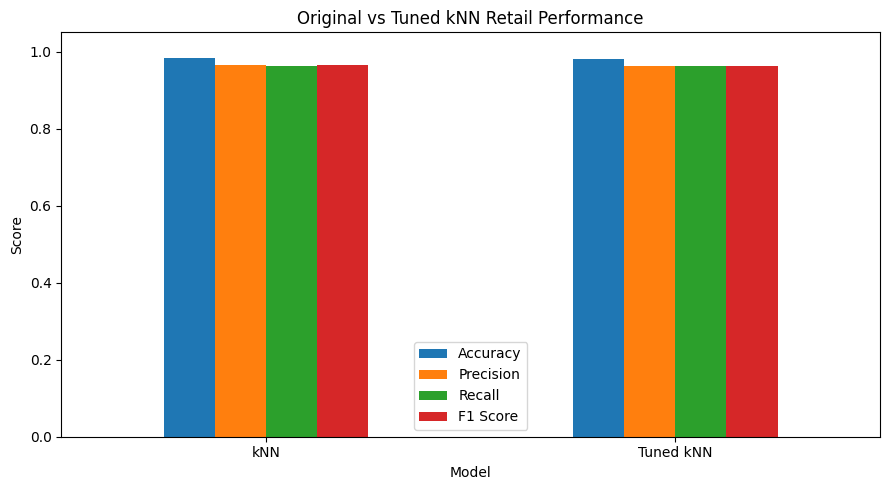

In [12]:
# =====================================================
# 10. ORIGINAL VS TUNED kNN COMPARISON
# =====================================================

knn_retail_comparison = pd.concat(
    [knn_retail_results, tuned_knn_retail_results],
    ignore_index=True
)

display(knn_retail_comparison.round(3))

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

knn_retail_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Original vs Tuned kNN Retail Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# 11. TRAIN VS TEST PERFORMANCE CHECK
# =====================================================

knn_train_pred = best_knn_retail.predict(X_train_r_scaled)

train_test_comparison = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [
        accuracy_score(y_train_r, knn_train_pred),
        accuracy_score(y_test_r, best_knn_retail_pred)
    ],
    "Precision": [
        precision_score(y_train_r, knn_train_pred, zero_division=0),
        precision_score(y_test_r, best_knn_retail_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_train_r, knn_train_pred, zero_division=0),
        recall_score(y_test_r, best_knn_retail_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_train_r, knn_train_pred, zero_division=0),
        f1_score(y_test_r, best_knn_retail_pred, zero_division=0)
    ]
})

display(train_test_comparison.round(3))

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Data,1.000,1.000,1.000,1.000
1,Testing Data,0.981,0.963,0.963,0.963


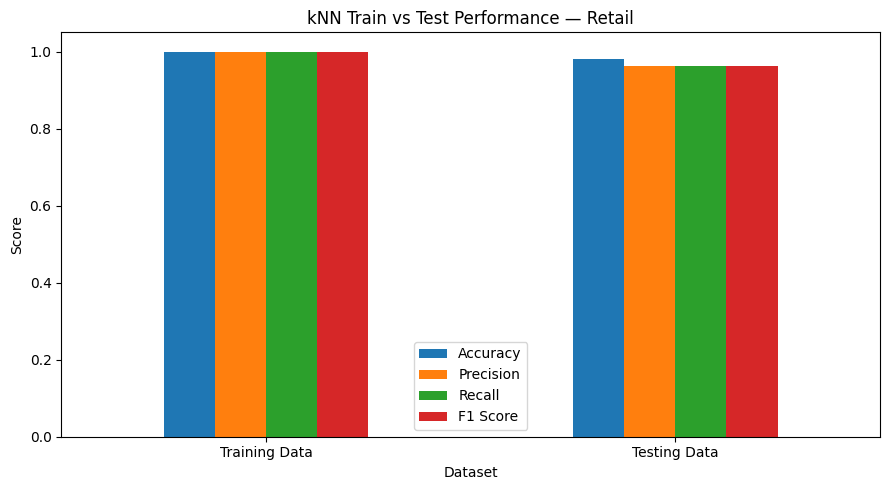

In [14]:
# =====================================================
# 12. TRAIN VS TEST PERFORMANCE VISUALISATION
# =====================================================

train_test_comparison.set_index("Dataset").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("kNN Train vs Test Performance — Retail")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

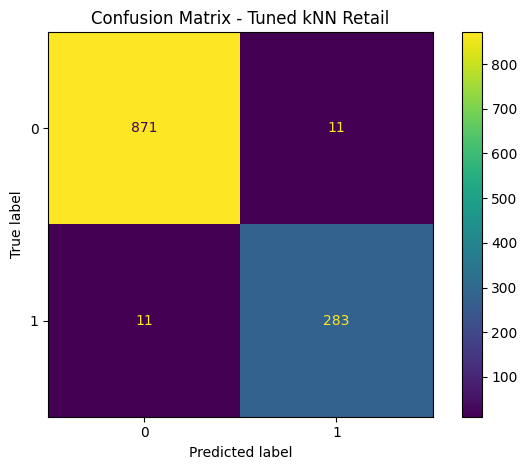

In [15]:
# =====================================================
# 13. CONFUSION MATRIX
# =====================================================

ConfusionMatrixDisplay.from_predictions(
    y_test_r,
    best_knn_retail_pred
)

plt.title("Confusion Matrix - Tuned kNN Retail")
plt.tight_layout()
plt.show()

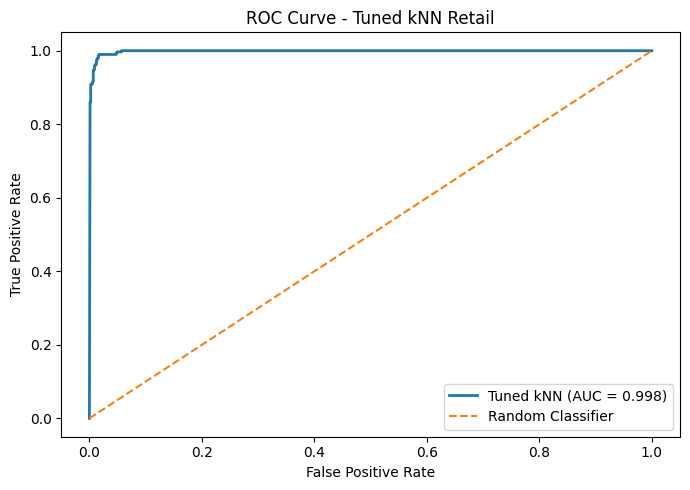

In [16]:
# =====================================================
# 14. ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(
    y_test_r,
    best_knn_retail_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Tuned kNN (AUC = {roc_auc_score(y_test_r, best_knn_retail_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Tuned kNN Retail")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# =====================================================
# 15. SAVE TUNED kNN RETAIL RESULTS
# =====================================================

tuned_knn_retail_results.to_csv(
    "../results/Knn_retail_results.csv",
    index=False
)

print("kNN retail results saved successfully.")

from google.colab import files
files.download("../results/Knn_retail_results.csv")

kNN retail results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## kNN Retail Summary

The k-Nearest Neighbours model was applied to the Online Retail dataset to classify customers as high-value or low-value. RFM-based features — Recency, Frequency, Monetary value, Average Basket Value, and Total Quantity — were used as input features, with log transformations applied to reduce skewness.

Since kNN is distance-based, feature scaling using StandardScaler was applied before training to ensure no single feature dominated the distance calculation.

Hyperparameter tuning using GridSearchCV with StratifiedKFold cross-validation was applied to find the best number of neighbours and weighting method. The tuned model was used for the final result.

The tuned kNN model achieved an Accuracy of 0.981, Precision of 0.963, Recall of 0.963, F1-score of 0.963, and ROC-AUC of 0.998. These results show that kNN was highly effective at distinguishing high-value from low-value customers.

The train vs test comparison showed consistent performance across both sets, indicating the model generalised well without overfitting.

The ROC curve confirmed very strong class separation with an AUC of 0.998. The confusion matrix showed that the model made very few misclassifications across both classes.

One limitation is that kNN can be computationally expensive on large datasets because prediction requires comparing each new record against all training examples. Feature scaling is also essential since unscaled features can distort distance measurements.